In [3]:
import pandas as pd

In [4]:
df=pd.read_csv("eg.csv")
df

,weight,texture,color,fruit
0,150,smooth,red,apple
1,170,rough,orange,orange
2,140,smooth,green,apple
3,180,rough,orange,orange
4,160,smooth,red,apple
5,155,rough,yellow,orange


In [5]:
import numpy as np
df['texture']=np.where(df['texture']=='smooth',0,1)
df

,weight,texture,color,fruit
0,150,0,red,apple
1,170,1,orange,orange
2,140,0,green,apple
3,180,1,orange,orange
4,160,0,red,apple
5,155,1,yellow,orange


In [6]:
df['color']=np.where(df['color']=='red',0,
                            np.where(df['color']=='orange',1,
                            np.where(df['color']=='green',2,3)))
df

,weight,texture,color,fruit
0,150,0,0,apple
1,170,1,1,orange
2,140,0,2,apple
3,180,1,1,orange
4,160,0,0,apple
5,155,1,3,orange


In [7]:
x=df[['weight','texture','color']]
y=df['fruit']
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [8]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy'
                                     ,n_estimators=100,random_state=42)
rf_classifier.fit(x,y)
prediction=rf_classifier.predict(x)
print(prediction)

['apple' 'orange' 'apple' 'orange' 'apple' 'orange']


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , confusion_matrix
cm= confusion_matrix (y,prediction)
print(cm)

[[3 0]
 [0 3]]


In [10]:
print("Acuuracy Score: ",accuracy_score(y,prediction))


Acuuracy Score:  1.0


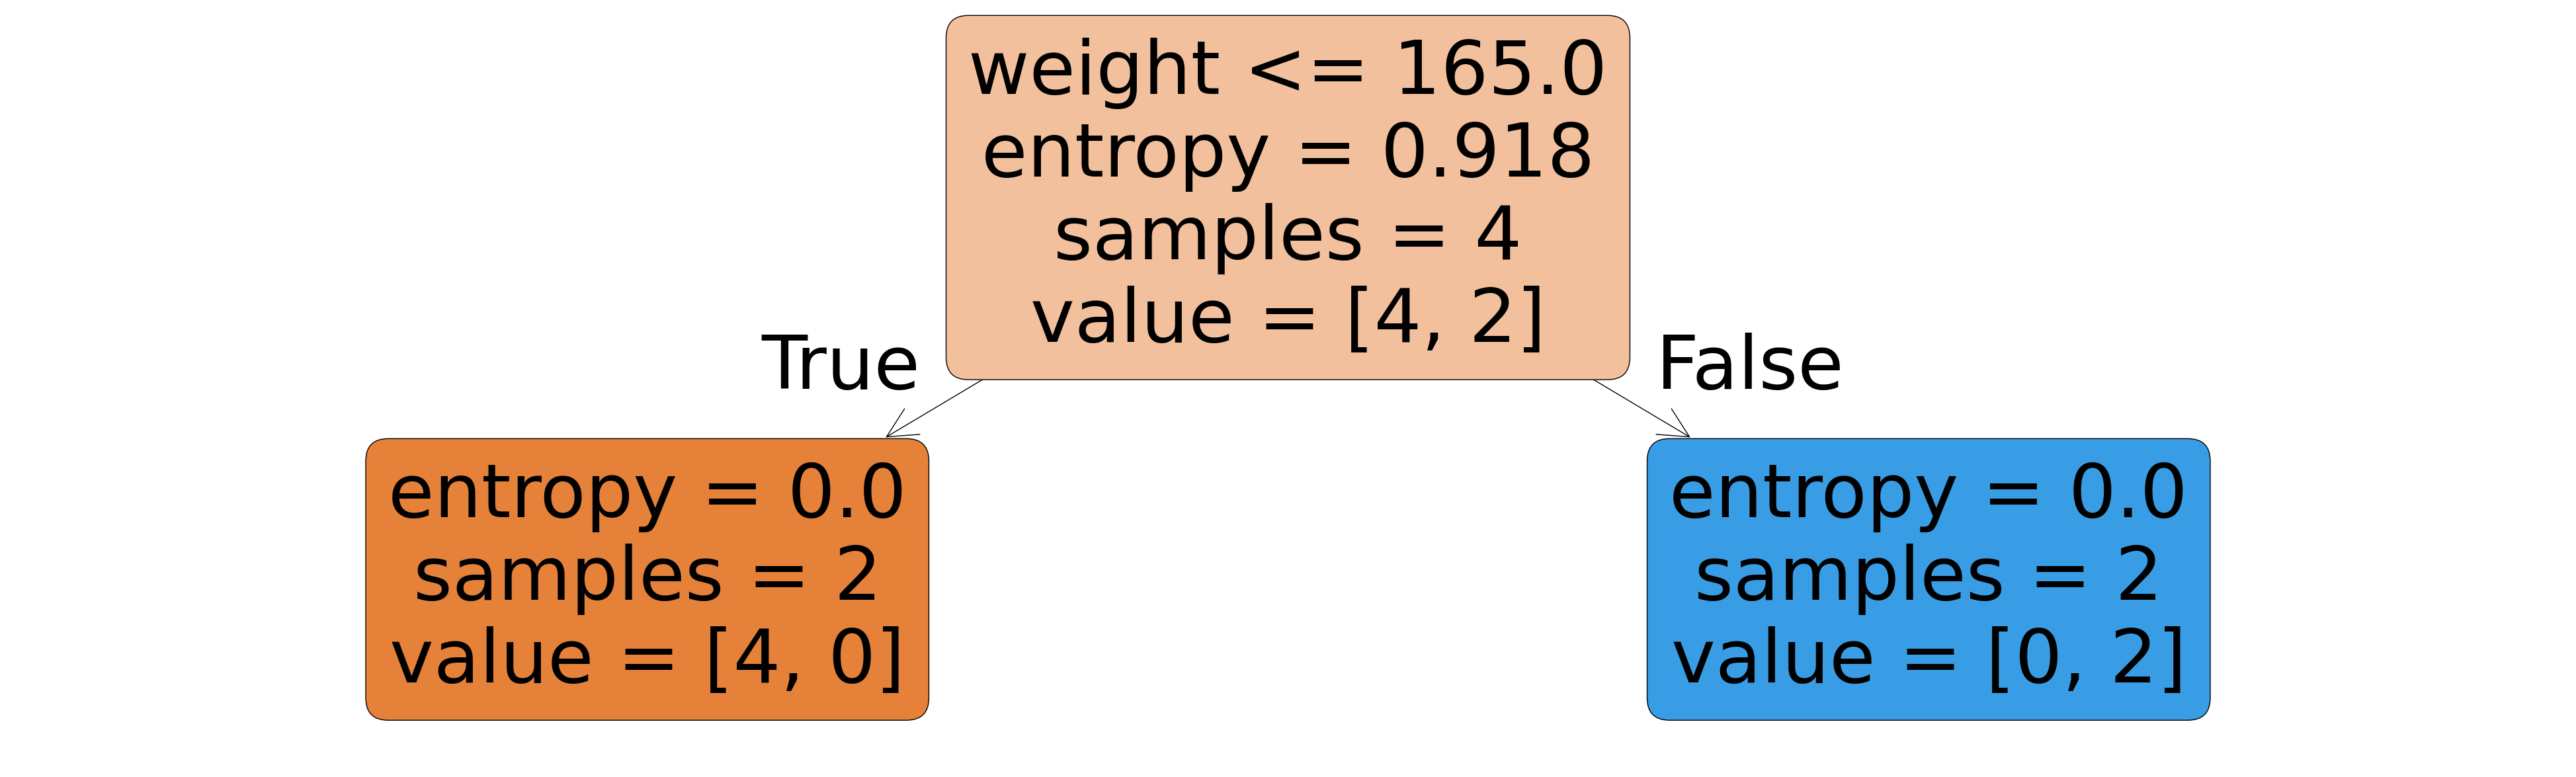

In [11]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(50,15))
choose_tree=rf_classifier.estimators_[0]
plot_tree(choose_tree,feature_names=x.columns,filled=True,rounded=True,)
plt.show()

# Support Vector Machiene
- SVM is famous for its ability to handle complex classification tasks
- ****Descion boundry**** - line that seperates the classes
- ****Margin**** - It maximizes the distance between the line and the nearest point of each class
- ****Support vectors**** - data points that sit right on the edge of 'street' . Mapping them goves the boundary values
- ****wx+b**** ---> w=weights b=bias
- ****C**** (Regularization)- controls the trade off between maximizing the margin and minimizing the ,isclassification
- ****High**** C - priorties the correct classification(error priority -high)
- ****Low**** C - allow more misclassification to achieve n(error priority-low)

In [18]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [19]:
x=df.iloc[:,0:8]
y=df["Outcome"]
print(x.shape)
print(y.shape)


(768, 8)
(768,)


In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1) 
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [23]:
from sklearn.svm import SVC
classifier=SVC(kernel='rbf',C=1.0,random_state=0)
model=classifier.fit(x_train,y_train)
y_pred =model.predict(x_test)
print(y_pred)

[0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0
 1 0 1 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0
 0 0 0 1 0 0]


In [25]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[93  6]
 [27 28]]


In [26]:
print("Acuuracy Score: ",accuracy_score(y_test,y_pred))

Acuuracy Score:  0.7857142857142857
